In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import find_dotenv
from dotenv import load_dotenv
# Load environment variables (ensure GROQ_API_KEY is set in your .env)
load_dotenv(find_dotenv())

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name) # -> "arxiv"

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name # -> "wikipedia"

tavily = TavilySearchResults()
tools = [arxiv, wiki, tavily]

C:\Users\itsar\AppData\Local\Temp\ipykernel_37012\224036419.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


arxiv


C:\Users\itsar\AppData\Local\Temp\ipykernel_37012\224036419.py:17: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [2]:
response = arxiv.invoke("Attention is all you need")
response

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [3]:
from dotenv import find_dotenv
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv(find_dotenv())

# Initialize Groq model
llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=0.7,
)

llm_with_tools = llm.bind_tools(tools)

In [7]:
from langchain_core.messages import HumanMessage
response = llm_with_tools.invoke([HumanMessage(content="What is the recent AI News")])
response.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest AI news July 2024'},
  'id': 'ff77w21g9',
  'type': 'tool_call'}]

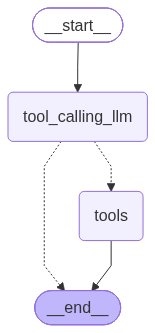

In [5]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", END)
graph = builder.compile()
graph

In [8]:
messages = graph.invoke({"messages": HumanMessage(content="1706.03762")})
messages

{'messages': [HumanMessage(content='1706.03762', additional_kwargs={}, response_metadata={}, id='270b22e9-09d1-49fe-a02e-39cc63e030d5'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'tqxb3b6bz', 'function': {'arguments': '{"query":"1706.03762"}', 'name': 'arxiv'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 527, 'total_tokens': 562, 'completion_time': 0.109428414, 'completion_tokens_details': None, 'prompt_time': 0.037216702, 'prompt_tokens_details': None, 'queue_time': 0.055661848, 'total_time': 0.146645116}, 'model_name': 'qwen/qwen3.8-27b', 'system_fingerprint': 'fp_424cb89518', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0a8dc-aabf-76b1-9046-e7d50f799c05-0', tool_calls=[{'name': 'arxiv', 'args': {'query': '1706.03762'}, 'id': 'tqxb3b6bz', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 527, 'output_toke

In [10]:
messages = graph.invoke({"messages": HumanMessage(content="Provide me the top 10 recent AI news for March 3rd 2025")})
messages

{'messages': [HumanMessage(content='Provide me the top 10 recent AI news for March 3rd 2025', additional_kwargs={}, response_metadata={}, id='2b4c8341-4b51-4c0c-8c6a-e30f076ce30c'),
  AIMessage(content="I'll search for the top AI news from March 3rd, 2025. Let me run several searches in parallel to get comprehensive coverage.\n\n", additional_kwargs={'tool_calls': [{'id': '9qaw0gbva', 'function': {'arguments': '{"query":"top AI news March 3 2025"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': '6xnj0tc9j', 'function': {'arguments': '{"query":"artificial intelligence announcements March 3 2025"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}, {'id': 'swftxtzq6', 'function': {'arguments': '{"query":"OpenAI Google Anthropic news March 3 2025"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 154, 'prompt_tokens': 537, 'total_tokens': 691, 'completion_time': 0.456576485, 'completion_t

In [11]:
messages = graph.invoke({"messages": HumanMessage(content="What is machine learning")})
messages

{'messages': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}, id='937c5073-bd7f-426a-8ef1-edbd1fa94cce'),
  AIMessage(content='Machine learning (ML) is a field of artificial intelligence (AI) that provides systems the ability to automatically learn and improve from experience without being explicitly programmed. Instead of following rigid, hand-coded rules, machine learning algorithms use data to identify patterns and make predictions or decisions.\n\nHere is a breakdown of the key concepts:\n\n### 1. How It Works\nAt a high level, machine learning involves three main components:\n*   **Data:** The raw input (e.g., images, text, numbers) used to train the model.\n*   **Model:** The algorithm or structure that learns from the data. This could be a neural network, a decision tree, or a linear regression model.\n*   **Learning Process:** The model analyzes the data, identifies patterns, and adjusts its internal parameters to minimize errors in 